TITLE
# Restaurant Recommendation System
This project builds a restaurant recommendation system using customer reviews and ratings. The system analyzes review text using sentiment analysis and combines it with star ratings to recommend the best restaurants.

DATA SELECTION
## Dataset

The Yelp dataset was used for this project. Two main datasets were used:

- Review dataset: contains customer reviews, ratings, and text
- Business dataset: contains restaurant details such as name, location, and categories

A sample of the review dataset was used due to the large size of the full dataset.

In [85]:
pip install pandas

You should consider upgrading via the '/Users/dilinithisari/Desktop/restaurant-project/.venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [86]:
!pip install scikit-learn

  Using cached scikit_learn-1.6.1-cp39-cp39-macosx_12_0_arm64.whl (11.1 MB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
  Using cached scipy-1.13.1-cp39-cp39-macosx_12_0_arm64.whl (30.3 MB)
You should consider upgrading via the '/Users/dilinithisari/Desktop/restaurant-project/.venv/bin/python3 -m pip install --upgrade pip' command.


In [87]:
import pandas as pd

reviews = pd.read_csv("yelp_reviews.csv")

reviews.head()

,business_id,stars,text,sentiment,label,score
0,XQfwVwDr-v0ZS3_CbbE5Xw,3,"If you decide to eat here, just be aware it is...",0.085278,Positive,2.125583
1,7ATYjTIgM3jUlt4UM3IypQ,5,I've taken a lot of spin classes over the year...,0.402273,Positive,3.620682
2,YjUWPpI6HXG530lwP-fb2A,3,Family diner. Had the buffet. Eclectic assortm...,0.139935,Positive,2.141981
3,kxX2SOes4o-D3ZQBkiMRfA,5,"Wow! Yummy, different, delicious. Our favo...",0.302557,Positive,3.590767
4,e4Vwtrqf-wpJfwesgvdgxQ,4,Cute interior and owner (?) gave us tour of up...,0.400969,Positive,2.920291


In [88]:
reviews = reviews[['business_id', 'stars', 'text']]

reviews.head()

,business_id,stars,text
0,XQfwVwDr-v0ZS3_CbbE5Xw,3,"If you decide to eat here, just be aware it is..."
1,7ATYjTIgM3jUlt4UM3IypQ,5,I've taken a lot of spin classes over the year...
2,YjUWPpI6HXG530lwP-fb2A,3,Family diner. Had the buffet. Eclectic assortm...
3,kxX2SOes4o-D3ZQBkiMRfA,5,"Wow! Yummy, different, delicious. Our favo..."
4,e4Vwtrqf-wpJfwesgvdgxQ,4,Cute interior and owner (?) gave us tour of up...


In [89]:
!pip install textblob

You should consider upgrading via the '/Users/dilinithisari/Desktop/restaurant-project/.venv/bin/python3 -m pip install --upgrade pip' command.


In [90]:
from textblob import TextBlob

In [91]:
reviews = pd.read_json(
    "yelp_dataset/yelp_academic_dataset_review.json",
    lines=True,
    nrows=50000
)

reviews = reviews[['business_id', 'stars', 'text']]
reviews.head()

,business_id,stars,text
0,XQfwVwDr-v0ZS3_CbbE5Xw,3,"If you decide to eat here, just be aware it is..."
1,7ATYjTIgM3jUlt4UM3IypQ,5,I've taken a lot of spin classes over the year...
2,YjUWPpI6HXG530lwP-fb2A,3,Family diner. Had the buffet. Eclectic assortm...
3,kxX2SOes4o-D3ZQBkiMRfA,5,"Wow! Yummy, different, delicious. Our favo..."
4,e4Vwtrqf-wpJfwesgvdgxQ,4,Cute interior and owner (?) gave us tour of up...


##### The datasets are imported into the notebook using pandas. Altogether 6 datasets are used. 

In [92]:
D1 = pd.read_csv("yelp_reviews.csv")
D1.dropna(how='all')
D1.drop_duplicates()

,business_id,stars,text,sentiment,label,score
0,XQfwVwDr-v0ZS3_CbbE5Xw,3,"If you decide to eat here, just be aware it is...",0.085278,Positive,2.125583
1,7ATYjTIgM3jUlt4UM3IypQ,5,I've taken a lot of spin classes over the year...,0.402273,Positive,3.620682
2,YjUWPpI6HXG530lwP-fb2A,3,Family diner. Had the buffet. Eclectic assortm...,0.139935,Positive,2.141981
3,kxX2SOes4o-D3ZQBkiMRfA,5,"Wow! Yummy, different, delicious. Our favo...",0.302557,Positive,3.590767
4,e4Vwtrqf-wpJfwesgvdgxQ,4,Cute interior and owner (?) gave us tour of up...,0.400969,Positive,2.920291
...,...,...,...,...,...,...
49995,GBTPC53ZrG1ZBY3DT8Mbcw,4,Came here first for breakfast and had their yu...,0.316250,Positive,2.894875
49996,EQ-TZ2eeD_E0BHuvoaeG5Q,2,Food was good. I had a decent breakfast but no...,0.280119,Positive,1.484036
49997,_RFqyBgklIBqOAM-zzV_WQ,3,It's cool that Second Image is trying. They so...,0.118056,Positive,2.135417
49998,8agPzX-O-8LEDjDNloSdzQ,4,"Best shrimp on the beach! Steamed to order, d...",0.173773,Positive,2.852132


In [93]:
D2 = pd.read_json(
    "yelp_dataset/yelp_academic_dataset_business.json",
    lines=True
)

D2.dropna(how='all')

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
0,Pns2l4eNsfO8kk83dixA6A,"Abby Rappoport, LAC, CMQ","1616 Chapala St, Ste 2",Santa Barbara,CA,93101,34.426679,-119.711197,5.0,7,0,{'ByAppointmentOnly': 'True'},"Doctors, Traditional Chinese Medicine, Naturop...",None
1,mpf3x-BjTdTEA3yCZrAYPw,The UPS Store,87 Grasso Plaza Shopping Center,Affton,MO,63123,38.551126,-90.335695,3.0,15,1,{'BusinessAcceptsCreditCards': 'True'},"Shipping Centers, Local Services, Notaries, Ma...","{'Monday': '0:0-0:0', 'Tuesday': '8:0-18:30', ..."
2,tUFrWirKiKi_TAnsVWINQQ,Target,5255 E Broadway Blvd,Tucson,AZ,85711,32.223236,-110.880452,3.5,22,0,"{'BikeParking': 'True', 'BusinessAcceptsCredit...","Department Stores, Shopping, Fashion, Home & G...","{'Monday': '8:0-22:0', 'Tuesday': '8:0-22:0', ..."
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ..."
4,mWMc6_wTdE0EUBKIGXDVfA,Perkiomen Valley Brewery,101 Walnut St,Green Lane,PA,18054,40.338183,-75.471659,4.5,13,1,"{'BusinessAcceptsCreditCards': 'True', 'Wheelc...","Brewpubs, Breweries, Food","{'Wednesday': '14:0-22:0', 'Thursday': '16:0-2..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150341,IUQopTMmYQG-qRtBk-8QnA,Binh's Nails,3388 Gateway Blvd,Edmonton,AB,T6J 5H2,53.468419,-113.492054,3.0,13,1,"{'ByAppointmentOnly': 'False', 'RestaurantsPri...","Nail Salons, Beauty & Spas","{'Monday': '10:0-19:30', 'Tuesday': '10:0-19:3..."
150342,c8GjPIOTGVmIemT7j5_SyQ,Wild Birds Unlimited,2813 Bransford Ave,Nashville,TN,37204,36.115118,-86.766925,4.0,5,1,"{'BusinessAcceptsCreditCards': 'True', 'Restau...","Pets, Nurseries & Gardening, Pet Stores, Hobby...","{'Monday': '9:30-17:30', 'Tuesday': '9:30-17:3..."
150343,_QAMST-NrQobXduilWEqSw,Claire's Boutique,"6020 E 82nd St, Ste 46",Indianapolis,IN,46250,39.908707,-86.065088,3.5,8,1,"{'RestaurantsPriceRange2': '1', 'BusinessAccep...","Shopping, Jewelry, Piercing, Toy Stores, Beaut...",None
150344,mtGm22y5c2UHNXDFAjaPNw,Cyclery & Fitness Center,2472 Troy Rd,Edwardsville,IL,62025,38.782351,-89.950558,4.0,24,1,"{'BusinessParking': '{'garage': False, 'street...","Fitness/Exercise Equipment, Eyewear & Optician...","{'Monday': '9:0-20:0', 'Tuesday': '9:0-20:0', ..."


In [94]:
D3 = pd.read_json(
    "yelp_dataset/yelp_academic_dataset_checkin.json",
    lines=True
)

D3.dropna(how='all')

,business_id,date
0,---kPU91CF4Lq2-WlRu9Lw,"2020-03-13 21:10:56, 2020-06-02 22:18:06, 2020..."
1,--0iUa4sNDFiZFrAdIWhZQ,"2010-09-13 21:43:09, 2011-05-04 23:08:15, 2011..."
2,--30_8IhuyMHbSOcNWd6DQ,"2013-06-14 23:29:17, 2014-08-13 23:20:22"
3,--7PUidqRWpRSpXebiyxTg,"2011-02-15 17:12:00, 2011-07-28 02:46:10, 2012..."
4,--7jw19RH9JKXgFohspgQw,"2014-04-21 20:42:11, 2014-04-28 21:04:46, 2014..."
...,...,...
131925,zznJox6-nmXlGYNWgTDwQQ,"2013-03-23 16:22:47, 2013-04-07 02:03:12, 2013..."
131926,zznZqH9CiAznbkV6fXyHWA,2021-06-12 01:16:12
131927,zzu6_r3DxBJuXcjnOYVdTw,"2011-05-24 01:35:13, 2012-01-01 23:44:33, 2012..."
131928,zzw66H6hVjXQEt0Js3Mo4A,"2016-12-03 23:33:26, 2018-12-02 19:08:45"


In [95]:
D4 = pd.read_json(
    "yelp_dataset/yelp_academic_dataset_review.json",
    lines=True,
    nrows=140000
)

D4.dropna(how='all')

,review_id,user_id,business_id,stars,useful,funny,cool,text,date
0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3,0,0,0,"If you decide to eat here, just be aware it is...",2018-07-07 22:09:11
1,BiTunyQ73aT9WBnpR9DZGw,OyoGAe7OKpv6SyGZT5g77Q,7ATYjTIgM3jUlt4UM3IypQ,5,1,0,1,I've taken a lot of spin classes over the year...,2012-01-03 15:28:18
2,saUsX_uimxRlCVr67Z4Jig,8g_iMtfSiwikVnbP2etR0A,YjUWPpI6HXG530lwP-fb2A,3,0,0,0,Family diner. Had the buffet. Eclectic assortm...,2014-02-05 20:30:30
3,AqPFMleE6RsU23_auESxiA,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,5,1,0,1,"Wow! Yummy, different, delicious. Our favo...",2015-01-04 00:01:03
4,Sx8TMOWLNuJBWer-0pcmoA,bcjbaE6dDog4jkNY91ncLQ,e4Vwtrqf-wpJfwesgvdgxQ,4,1,0,1,Cute interior and owner (?) gave us tour of up...,2017-01-14 20:54:15
...,...,...,...,...,...,...,...,...,...
139995,n8HInOp2dWb6a6eSEkfQ2g,jUhfkUm6GdRDkDvCOVMetg,seKihQKpGGnCeLuELRQPSQ,3,2,0,0,"Pros: Decor, Alcohol variety, Simple menu sele...",2015-02-22 15:10:08
139996,F_W-0VERPGOFUXaeO9pnCg,8aZ1RG-46VIg4OrM0K-yqQ,JvawJ9bSr22xn4R9oLvl_w,5,0,0,0,I just could not stay away from this place. I ...,2016-07-29 08:32:10
139997,VeOBIypKw8zK3izsP3_BQg,o5IVxc8EwtYZp81TAeoedg,oGdbvXKXVCQ8WC_GQePDkQ,5,0,0,0,This was my sister and I's first time there an...,2016-04-17 20:46:50
139998,7DcwbHAY33Rvz0rRP7oI-g,Ny8NnREFL894xTsfbP7QLA,sGbjViru0iJfxH5cBpMeHQ,3,1,0,1,"Great Chinese food, presented beautifully. May...",2012-10-23 22:04:25


In [96]:
D5 = pd.read_json(
    "yelp_dataset/yelp_academic_dataset_tip.json",
    lines=True,
    nrows=140000
)

D5.dropna(how='all')

,user_id,business_id,text,date,compliment_count
0,AGNUgVwnZUey3gcPCJ76iw,3uLgwr0qeCNMjKenHJwPGQ,Avengers time with the ladies.,2012-05-18 02:17:21,0
1,NBN4MgHP9D3cw--SnauTkA,QoezRbYQncpRqyrLH6Iqjg,They have lots of good deserts and tasty cuban...,2013-02-05 18:35:10,0
2,-copOvldyKh1qr-vzkDEvw,MYoRNLb5chwjQe3c_k37Gg,It's open even when you think it isn't,2013-08-18 00:56:08,0
3,FjMQVZjSqY8syIO-53KFKw,hV-bABTK-glh5wj31ps_Jw,Very decent fried chicken,2017-06-27 23:05:38,0
4,ld0AperBXk1h6UbqmM80zw,_uN0OudeJ3Zl_tf6nxg5ww,Appetizers.. platter special for lunch,2012-10-06 19:43:09,0
...,...,...,...,...,...
139995,ALehxcwDM8U1b02qbwKgOA,Ld7wYAcFvyErl_RfLc-uiA,I can't believe I'm writing this bc indian foo...,2014-10-24 15:27:38,0
139996,l4LOCGuckB8ypPUrGnNbag,qcPU5zGuX5yh-m2nd6xQVA,Not even cream can help their coffee it's that...,2017-01-12 12:50:36,0
139997,iPkdNziqnhNukjnmsrSzmg,bbcQyfYSAD5B-0FcDhEKmg,Closed,2012-01-06 23:35:57,0
139998,seo-RYlwa8yYkvrBmmdKrg,_fAhTRXw4bDaxqmzseSWJg,Amazing pizza!,2014-04-20 00:17:04,0


In [97]:
D6 = pd.read_json(
    "yelp_dataset/yelp_academic_dataset_user.json",
    lines=True,
    nrows=140000
)

D6.dropna(how='all')

,user_id,name,review_count,yelping_since,useful,funny,cool,elite,friends,fans,...,compliment_more,compliment_profile,compliment_cute,compliment_list,compliment_note,compliment_plain,compliment_cool,compliment_funny,compliment_writer,compliment_photos
0,qVc8ODYU5SZjKXVBgXdI7w,Walker,585,2007-01-25 16:47:26,7217,1259,5994,2007,"NSCy54eWehBJyZdG2iE84w, pe42u7DcCH2QmI81NX-8qA...",267,...,65,55,56,18,232,844,467,467,239,180
1,j14WgRoU_-2ZE1aw1dXrJg,Daniel,4333,2009-01-25 04:35:42,43091,13066,27281,"2009,2010,2011,2012,2013,2014,2015,2016,2017,2...","ueRPE0CX75ePGMqOFVj6IQ, 52oH4DrRvzzl8wh5UXyU0A...",3138,...,264,184,157,251,1847,7054,3131,3131,1521,1946
2,2WnXYQFK0hXEoTxPtV2zvg,Steph,665,2008-07-25 10:41:00,2086,1010,1003,"2009,2010,2011,2012,2013","LuO3Bn4f3rlhyHIaNfTlnA, j9B4XdHUhDfTKVecyWQgyA...",52,...,13,10,17,3,66,96,119,119,35,18
3,SZDeASXq7o05mMNLshsdIA,Gwen,224,2005-11-29 04:38:33,512,330,299,"2009,2010,2011","enx1vVPnfdNUdPho6PH_wg, 4wOcvMLtU6a9Lslggq74Vg...",28,...,4,1,6,2,12,16,26,26,10,9
4,hA5lMy-EnncsH4JoR-hFGQ,Karen,79,2007-01-05 19:40:59,29,15,7,,"PBK4q9KEEBHhFvSXCUirIw, 3FWPpM7KU1gXeOM_ZbYMbA...",1,...,1,0,0,0,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139995,y6ZwhoQIQy0pbh2j9A9TfA,Tara,5,2013-01-23 15:49:55,4,0,2,,None,0,...,0,0,0,0,0,1,0,0,0,0
139996,OBIvgjl-FZNBnc2jSsL3kw,Linda,7,2012-12-15 16:22:17,4,1,1,,None,0,...,1,0,0,0,0,0,0,0,0,0
139997,vWDPyimplnVmvu8jj-HkOQ,Reen,6,2015-02-01 03:22:31,0,0,0,,None,0,...,0,0,0,0,0,0,0,0,0,0
139998,o-gSDuZVDSBAS8BdtYlshw,Edward,21,2012-11-23 06:50:25,6,0,1,,None,0,...,0,0,0,0,0,0,0,0,0,0


In [98]:
Res = D2[D2['categories'].str.contains('Food', case=False, na=False)]
Res = Res[Res['is_open'] == 1]

Res.dropna(how='all')

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ..."
4,mWMc6_wTdE0EUBKIGXDVfA,Perkiomen Valley Brewery,101 Walnut St,Green Lane,PA,18054,40.338183,-75.471659,4.5,13,1,"{'BusinessAcceptsCreditCards': 'True', 'Wheelc...","Brewpubs, Breweries, Food","{'Wednesday': '14:0-22:0', 'Thursday': '16:0-2..."
5,CF33F8-E6oudUQ46HnavjQ,Sonic Drive-In,615 S Main St,Ashland City,TN,37015,36.269593,-87.058943,2.0,6,1,"{'BusinessParking': 'None', 'BusinessAcceptsCr...","Burgers, Fast Food, Sandwiches, Food, Ice Crea...","{'Monday': '0:0-0:0', 'Tuesday': '6:0-22:0', '..."
9,bBDDEgkFA1Otx9Lfe7BZUQ,Sonic Drive-In,2312 Dickerson Pike,Nashville,TN,37207,36.208102,-86.768170,1.5,10,1,"{'RestaurantsAttire': ''casual'', 'Restaurants...","Ice Cream & Frozen Yogurt, Fast Food, Burgers,...","{'Monday': '0:0-0:0', 'Tuesday': '6:0-21:0', '..."
11,eEOYSgkmpB90uNA7lDOMRA,Vietnamese Food Truck,,Tampa Bay,FL,33602,27.955269,-82.456320,4.0,10,1,"{'Alcohol': ''none'', 'OutdoorSeating': 'None'...","Vietnamese, Food, Restaurants, Food Trucks","{'Monday': '11:0-14:0', 'Tuesday': '11:0-14:0'..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150321,AM7O0cwkxm6w_e0Q7-f9FQ,Starbucks,8817 S US-31,Indianapolis,IN,46227,39.638245,-86.128069,4.0,29,1,"{'RestaurantsPriceRange2': '1', 'Caters': 'Fal...","Food, Coffee & Tea","{'Monday': '6:0-21:0', 'Tuesday': '6:0-21:0', ..."
150325,l9eLGG9ZKpLJzboZq-9LRQ,Wawa,19 N Bishop Ave,Clifton Heights,PA,19018,39.925656,-75.310344,3.0,11,1,"{'BikeParking': 'True', 'BusinessAcceptsCredit...","Restaurants, Sandwiches, Convenience Stores, C...","{'Monday': '0:0-0:0', 'Tuesday': '0:0-0:0', 'W..."
150327,cM6V90ExQD6KMSU3rRB5ZA,Dutch Bros Coffee,1181 N Milwaukee St,Boise,ID,83704,43.615401,-116.284689,4.0,33,1,"{'WiFi': ''free'', 'RestaurantsGoodForGroups':...","Cafes, Juice Bars & Smoothies, Coffee & Tea, R...","{'Monday': '0:0-0:0', 'Tuesday': '0:0-17:0', '..."
150328,1jx1sfgjgVg0nM6n3p0xWA,Savaya Coffee Market,11177 N Oracle Rd,Oro Valley,AZ,85737,32.409552,-110.943073,4.5,41,1,"{'BusinessParking': '{'garage': False, 'street...","Specialty Food, Food, Coffee & Tea, Coffee Roa...","{'Monday': '0:0-0:0', 'Tuesday': '6:0-14:0', '..."


In [99]:
Combined_Res = pd.merge(Res, D1, on = 'business_id', how='left')
Combined_Res.dropna(how='all')

,business_id,name,address,city,state,postal_code,latitude,longitude,stars_x,review_count,is_open,attributes,categories,hours,stars_y,text,sentiment,label,score
0,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ...",4.0,This is nice little Chinese bakery in the hear...,0.251823,Positive,2.875547
1,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ...",4.0,This is the bakery I usually go to in Chinatow...,0.123958,Positive,2.837188
2,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ...",5.0,"A delightful find in Chinatown! Very clean, an...",0.713452,Positive,3.714036
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ...",5.0,I ordered a graduation cake for my niece and i...,0.575000,Positive,3.672500
4,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ...",4.0,HK-STYLE MILK TEA: FOUR STARS\n\nNot quite su...,0.162872,Positive,2.848862
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40413,AM7O0cwkxm6w_e0Q7-f9FQ,Starbucks,8817 S US-31,Indianapolis,IN,46227,39.638245,-86.128069,4.0,29,1,"{'RestaurantsPriceRange2': '1', 'Caters': 'Fal...","Food, Coffee & Tea","{'Monday': '6:0-21:0', 'Tuesday': '6:0-21:0', ...",NaN,NaN,NaN,NaN,NaN
40414,l9eLGG9ZKpLJzboZq-9LRQ,Wawa,19 N Bishop Ave,Clifton Heights,PA,19018,39.925656,-75.310344,3.0,11,1,"{'BikeParking': 'True', 'BusinessAcceptsCredit...","Restaurants, Sandwiches, Convenience Stores, C...","{'Monday': '0:0-0:0', 'Tuesday': '0:0-0:0', 'W...",NaN,NaN,NaN,NaN,NaN
40415,cM6V90ExQD6KMSU3rRB5ZA,Dutch Bros Coffee,1181 N Milwaukee St,Boise,ID,83704,43.615401,-116.284689,4.0,33,1,"{'WiFi': ''free'', 'RestaurantsGoodForGroups':...","Cafes, Juice Bars & Smoothies, Coffee & Tea, R...","{'Monday': '0:0-0:0', 'Tuesday': '0:0-17:0', '...",NaN,NaN,NaN,NaN,NaN
40416,1jx1sfgjgVg0nM6n3p0xWA,Savaya Coffee Market,11177 N Oracle Rd,Oro Valley,AZ,85737,32.409552,-110.943073,4.5,41,1,"{'BusinessParking': '{'garage': False, 'street...","Specialty Food, Food, Coffee & Tea, Coffee Roa...","{'Monday': '0:0-0:0', 'Tuesday': '6:0-14:0', '...",NaN,NaN,NaN,NaN,NaN


In [100]:
ombined_Res = pd.merge(Res, D4[['text', 'business_id']], on='business_id', how='left')
Combined_Res.dropna()

,business_id,name,address,city,state,postal_code,latitude,longitude,stars_x,review_count,is_open,attributes,categories,hours,stars_y,text,sentiment,label,score
0,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ...",4.0,This is nice little Chinese bakery in the hear...,0.251823,Positive,2.875547
1,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ...",4.0,This is the bakery I usually go to in Chinatow...,0.123958,Positive,2.837188
2,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ...",5.0,"A delightful find in Chinatown! Very clean, an...",0.713452,Positive,3.714036
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ...",5.0,I ordered a graduation cake for my niece and i...,0.575000,Positive,3.672500
4,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ...",4.0,HK-STYLE MILK TEA: FOUR STARS\n\nNot quite su...,0.162872,Positive,2.848862
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16461,Oun4NN-u5yiHIxDqtJnxgA,Federal Donuts,1219 S 2nd St,Philadelphia,PA,19147,39.932223,-75.147463,4.0,530,1,"{'RestaurantsGoodForGroups': 'False', 'GoodFor...","Restaurants, Korean, American (Traditional), B...","{'Monday': '8:0-15:0', 'Tuesday': '8:0-15:0', ...",5.0,Nothing could be better. I went in the morning...,0.044444,Positive,3.513333
16462,Oun4NN-u5yiHIxDqtJnxgA,Federal Donuts,1219 S 2nd St,Philadelphia,PA,19147,39.932223,-75.147463,4.0,530,1,"{'RestaurantsGoodForGroups': 'False', 'GoodFor...","Restaurants, Korean, American (Traditional), B...","{'Monday': '8:0-15:0', 'Tuesday': '8:0-15:0', ...",4.0,Donuts are amazing. There is nothing that com...,-0.025000,Negative,2.792500
16463,bfY9Z5zOihXRrR2aqVqHXQ,Schnucks - Brentwood,8800 Manchester Rd,Brentwood,MO,63144,38.611343,-90.350036,2.5,24,1,"{'BusinessParking': '{'garage': False, 'street...","Drugstores, Grocery, Bakeries, Food, Flowers &...","{'Monday': '6:0-21:0', 'Tuesday': '6:0-21:0', ...",3.0,"Decent schnucks location, my biggest gripe is ...",0.005556,Positive,2.101667
16464,bfY9Z5zOihXRrR2aqVqHXQ,Schnucks - Brentwood,8800 Manchester Rd,Brentwood,MO,63144,38.611343,-90.350036,2.5,24,1,"{'BusinessParking': '{'garage': False, 'street...","Drugstores, Grocery, Bakeries, Food, Flowers &...","{'Monday': '6:0-21:0', 'Tuesday': '6:0-21:0', ...",4.0,Hoping I have the right Schnucks but I'd have ...,0.240247,Positive,2.872074


In [101]:
Combined_Res = pd.merge(Res, D5[['text', 'business_id']], on='business_id', how='left')
Combined_Res.dropna()

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours,text
0,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ...",Love their pastries and drinks!
1,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ...",Really good egg tart and bubble tea. Best we ...
2,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ...",Was told they stopped making almond tarts... U...
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ...",After 6 pm the bread is on sale!
4,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ...",Best steamed pork bun in chinatown!
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57465,1jx1sfgjgVg0nM6n3p0xWA,Savaya Coffee Market,11177 N Oracle Rd,Oro Valley,AZ,85737,32.409552,-110.943073,4.5,41,1,"{'BusinessParking': '{'garage': False, 'street...","Specialty Food, Food, Coffee & Tea, Coffee Roa...","{'Monday': '0:0-0:0', 'Tuesday': '6:0-14:0', '...",Sumatra is the drip of the afternoon.
57466,1jx1sfgjgVg0nM6n3p0xWA,Savaya Coffee Market,11177 N Oracle Rd,Oro Valley,AZ,85737,32.409552,-110.943073,4.5,41,1,"{'BusinessParking': '{'garage': False, 'street...","Specialty Food, Food, Coffee & Tea, Coffee Roa...","{'Monday': '0:0-0:0', 'Tuesday': '6:0-14:0', '...",The Dominican Republic Science (ice drip) is v...
57467,1jx1sfgjgVg0nM6n3p0xWA,Savaya Coffee Market,11177 N Oracle Rd,Oro Valley,AZ,85737,32.409552,-110.943073,4.5,41,1,"{'BusinessParking': '{'garage': False, 'street...","Specialty Food, Food, Coffee & Tea, Coffee Roa...","{'Monday': '0:0-0:0', 'Tuesday': '6:0-14:0', '...",Best price I've seen anywhere. Great product t...
57468,1jx1sfgjgVg0nM6n3p0xWA,Savaya Coffee Market,11177 N Oracle Rd,Oro Valley,AZ,85737,32.409552,-110.943073,4.5,41,1,"{'BusinessParking': '{'garage': False, 'street...","Specialty Food, Food, Coffee & Tea, Coffee Roa...","{'Monday': '0:0-0:0', 'Tuesday': '6:0-14:0', '...",They have flowers! Yea!


In [102]:
Reviews = (Combined_Res.groupby('name', as_index=False)
           .agg(
               Total_Reviews=('review_count', 'sum'),
               Avg_Rating=('stars', 'mean')
           )
           .sort_values(by='Total_Reviews', ascending=False))
print(Reviews)

                                      name  Total_Reviews  Avg_Rating
254                      Acme Oyster House         662473    4.000000
7930                                  Luke         405306    4.000000
8771                   Mother's Restaurant         347395    3.500000
3629                                  Datz         316405    3.994898
9757                    Pappy's Smokehouse         275931    4.500000
...                                    ...            ...         ...
10388                 Prep And Save - Reno              5    4.000000
4431                         Europa Market              5    4.500000
4432   Europe Delicious Bakery and Grocery              5    5.000000
4433             European Bakery & Grocery              5    5.000000
0                     $5 Fresh Burger Stop              5    5.000000

[15391 rows x 3 columns]


/Users/dilinithisari/Desktop/restaurant-project/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/dilinithisari/Desktop/restaurant-project/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/dilinithisari/Desktop/restaurant-project/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/dilinithisari/Desktop/restaurant-project/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/dilinithisari/Desktop/restaurant-project/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/dilinithisari/Desktop/restaurant-projec

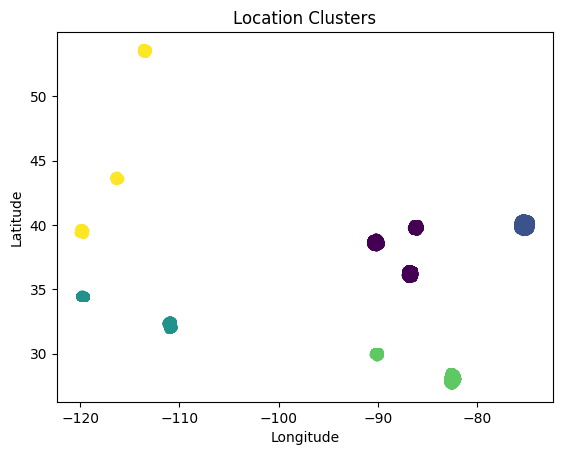

In [103]:
from sklearn.cluster import KMeans

coords = Combined_Res[['latitude', 'longitude']]

kmeans = KMeans(n_clusters = 5)
Combined_Res['location_cluster'] = kmeans.fit_predict(coords)

plt.scatter(
    Combined_Res['longitude'],
    Combined_Res['latitude'],
    c=Combined_Res['location_cluster']
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Location Clusters")
plt.show()

## Recommendation Model (Dilni Thisari)

In this part, a recommendation model was developed using both ratings and review text sentiment.

First, sentiment analysis was applied to the review text using the TextBlob library. This converts each review into a sentiment polarity score ranging from negative to positive.

Then, a final recommendation score was calculated using the following formula:

Score = (0.7 × rating) + (0.3 × sentiment)

This formula gives more importance to ratings while still considering the sentiment of the reviews.

Finally, restaurants were grouped and ranked based on their average score to generate the top recommendations.

In [104]:
def get_sentiment(text):
    return TextBlob(str(text)).sentiment.polarity

reviews['sentiment'] = reviews['text'].apply(get_sentiment)

reviews.head()

,business_id,stars,text,sentiment
0,XQfwVwDr-v0ZS3_CbbE5Xw,3,"If you decide to eat here, just be aware it is...",0.085278
1,7ATYjTIgM3jUlt4UM3IypQ,5,I've taken a lot of spin classes over the year...,0.402273
2,YjUWPpI6HXG530lwP-fb2A,3,Family diner. Had the buffet. Eclectic assortm...,0.139935
3,kxX2SOes4o-D3ZQBkiMRfA,5,"Wow! Yummy, different, delicious. Our favo...",0.302557
4,e4Vwtrqf-wpJfwesgvdgxQ,4,Cute interior and owner (?) gave us tour of up...,0.400969


## Sentiment Classification

Reviews were classified into positive and negative categories based on sentiment scores.

In [105]:
reviews['label'] = reviews['sentiment'].apply(
    lambda x: 'Positive' if x > 0 else 'Negative'
)

reviews[['text', 'sentiment', 'label']].head()

,text,sentiment,label
0,"If you decide to eat here, just be aware it is...",0.085278,Positive
1,I've taken a lot of spin classes over the year...,0.402273,Positive
2,Family diner. Had the buffet. Eclectic assortm...,0.139935,Positive
3,"Wow! Yummy, different, delicious. Our favo...",0.302557,Positive
4,Cute interior and owner (?) gave us tour of up...,0.400969,Positive


## Sentiment Distribution

The number of positive and negative reviews was analyzed to understand overall customer feedback.

In [106]:
positive_reviews = reviews[reviews['label'] == 'Positive']
negative_reviews = reviews[reviews['label'] == 'Negative']

print("Positive reviews:", len(positive_reviews))
print("Negative reviews:", len(negative_reviews))

Positive reviews: 44545
Negative reviews: 5455


In [107]:
reviews['score'] = (reviews['stars'] * 0.7) + (reviews['sentiment'] * 0.3)

In [108]:
#business = pd.read_json(
 #   "yelp_dataset/yelp_academic_dataset_business.json",
  #  lines=True
#)
business = pd.read_csv("yelp_business.csv")
business = business[business['categories'].str.contains('Restaurant', na=False)]

data = pd.merge(reviews, business, on='business_id')

data.shape



(36150, 19)

In [109]:
recommendations = data.groupby('name').agg({
    'score': 'mean',
    'stars_y': 'first',
    'review_count': 'first',
    'city': 'first'
}).reset_index()

top_restaurants = recommendations.sort_values(by='score', ascending=False).head(10)

top_restaurants

,name,score,stars_y,review_count,city
638,Copper Vine,3.764258,4.5,350,New Orleans
3072,Zesty Tsunami,3.742357,4.0,5,New Port Richey
1547,Luigi's Cafe,3.734000,4.5,63,Hockessin
1241,Ithai & Sushi Restaurant,3.726875,4.0,63,Largo
2481,Stokehold Restaurant,3.725000,4.5,13,New Orleans
2894,Twistee Treat - Sheldon,3.722500,4.0,58,Tampa
770,Due Lune Cucina,3.717500,4.0,79,Santa Barbara
737,Dominick's Pizzeria and Restaurant,3.705714,4.5,38,Plumsteadville
2161,Rib Station,3.705000,3.5,7,Bridgeton
2498,Sun-Rise Baking Company,3.702500,4.0,7,Tucson


In [110]:
recommendations.to_csv("recommendations.csv", index=False)

In [111]:
!pip install matplotlib

You should consider upgrading via the '/Users/dilinithisari/Desktop/restaurant-project/.venv/bin/python3 -m pip install --upgrade pip' command.


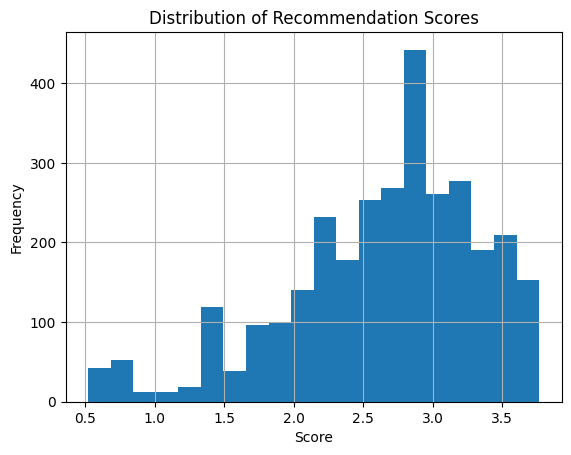

In [112]:
import matplotlib.pyplot as plt

recommendations['score'].hist(bins=20)
plt.title("Distribution of Recommendation Scores")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()

## Model Evaluation

The recommendation system combines star ratings (70%) and sentiment (30%).  

This improves accuracy because:
- Star ratings show overall satisfaction  
- Sentiment captures detailed user opinions  

This hybrid approach provides better recommendations than using ratings alone.

In [113]:
reviews.to_csv("yelp_reviews.csv", index=False)

In [114]:
business.to_csv("yelp_business.csv", index=False)

In [115]:
business.to_csv("business.csv", index=False)

In [116]:
csv_reviews = pd.read_csv("yelp_reviews.csv")

print(reviews.shape)
print(csv_reviews.shape)

(50000, 6)
(50000, 6)


## Results

The system successfully generated a list of top recommended restaurants based on the calculated scores.

Restaurants with high ratings and positive sentiment scores were ranked higher. This shows that combining ratings with sentiment analysis improves the quality of recommendations.

## Conclusion

This project demonstrates how sentiment analysis and ratings can be combined to build a simple but effective recommendation system.

The model provides meaningful restaurant recommendations and can be further improved by adding more advanced techniques such as user-based recommendations or topic modeling.

## Individual Contribution

I was responsible for developing the recommendation model. I performed sentiment analysis on review text and combined it with ratings to create a recommendation score. I also generated the final list of recommended restaurants.